In [1]:
# Reward 分布统计（按 step）
# 目标：与 scripts/reward_dist_by_step.py 统计逻辑一致，并额外输出各 step 的直方图

from __future__ import annotations

import json
import math
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import matplotlib.pyplot as plt

# ====== 你可以在这里改路径 ======
INPUT_JSONL = Path("/root/autodl-tmp/step-proof/results/fdg_builder_grpo/reward_samples/train_reward_samples.jsonl")
OUT_DIR = Path("/root/autodl-tmp/step-proof/results/fdg_builder_grpo/reward_samples/reward_cnt_nb")
REWARD_FIELD = "reward"  # 也可以改成 "score"

BIN_MIN = -1.0
BIN_MAX = 1.0
BIN_WIDTH = 0.05

OUT_DIR.mkdir(parents=True, exist_ok=True)

print("input:", INPUT_JSONL)
print("out_dir:", OUT_DIR)
print("reward_field:", REWARD_FIELD)


input: /root/autodl-tmp/step-proof/results/fdg_builder_grpo/reward_samples/train_reward_samples.jsonl
out_dir: /root/autodl-tmp/step-proof/results/fdg_builder_grpo/reward_samples/reward_cnt_nb
reward_field: reward


In [2]:
@dataclass
class OnlineStats:
    n: int = 0
    mean: float = 0.0
    m2: float = 0.0
    min_v: float = math.inf
    max_v: float = -math.inf

    def add(self, x: float) -> None:
        self.n += 1
        delta = x - self.mean
        self.mean += delta / self.n
        delta2 = x - self.mean
        self.m2 += delta * delta2
        if x < self.min_v:
            self.min_v = x
        if x > self.max_v:
            self.max_v = x

    def var_pop(self) -> float:
        return self.m2 / self.n if self.n else 0.0

    def std_pop(self) -> float:
        return math.sqrt(self.var_pop())


@dataclass
class StepAgg:
    step: int
    stats: OnlineStats = field(default_factory=OnlineStats)
    missing_reward: int = 0
    invalid_reward: int = 0
    hist: List[int] = field(default_factory=list)

    def ensure_hist(self, n_bins: int) -> None:
        if not self.hist:
            self.hist = [0] * n_bins


def iter_jsonl(path: Path) -> Iterable[Dict[str, Any]]:
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for line_no, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            if not isinstance(obj, dict):
                raise RuntimeError(f"Expected object at line {line_no}, got {type(obj).__name__}")
            yield obj


def _to_int_step(value: Any) -> Optional[int]:
    if value is None:
        return None
    if isinstance(value, bool):
        return None
    if isinstance(value, int):
        return value
    if isinstance(value, str) and value.strip().isdigit():
        return int(value.strip())
    return None


def _to_float(value: Any) -> Optional[float]:
    if value is None:
        return None
    if isinstance(value, bool):
        return None
    if isinstance(value, (int, float)):
        x = float(value)
        return x if math.isfinite(x) else None
    if isinstance(value, str):
        try:
            x = float(value.strip())
        except Exception:
            return None
        return x if math.isfinite(x) else None
    return None


def build_bins(bin_min: float, bin_max: float, bin_width: float) -> Tuple[List[float], List[str]]:
    if not (bin_width > 0):
        raise ValueError("BIN_WIDTH must be > 0")
    if not (bin_max > bin_min):
        raise ValueError("BIN_MAX must be > BIN_MIN")
    n_bins = int(math.ceil((bin_max - bin_min) / bin_width))
    edges = [bin_min + i * bin_width for i in range(n_bins + 1)]
    labels = [f"[{edges[i]:.4g},{edges[i+1]:.4g})" for i in range(n_bins)]
    labels[-1] = f"[{edges[-2]:.4g},{edges[-1]:.4g}]"  # inclusive last bin
    return edges, labels


def _bin_index(x: float, *, bmin: float, bmax: float, bw: float, n_bins: int) -> Optional[int]:
    if x < bmin or x > bmax:
        return None
    if x == bmax:
        return n_bins - 1
    idx = int((x - bmin) / bw)
    if 0 <= idx < n_bins:
        return idx
    return None


In [3]:
edges, bin_labels = build_bins(BIN_MIN, BIN_MAX, BIN_WIDTH)
N_BINS = len(bin_labels)

per_step: Dict[int, StepAgg] = {}
global_stats = OnlineStats()
global_hist = [0] * N_BINS

# counters
records = 0
rollouts_seen = 0
missing_step_records = 0
missing_rollouts_records = 0

for rec in iter_jsonl(INPUT_JSONL):
    records += 1
    step = _to_int_step(rec.get("step"))
    if step is None:
        missing_step_records += 1
        continue

    agg = per_step.get(step)
    if agg is None:
        agg = StepAgg(step=step)
        agg.ensure_hist(N_BINS)
        per_step[step] = agg
    else:
        agg.ensure_hist(N_BINS)

    rollouts = rec.get("rollouts")
    if not isinstance(rollouts, list):
        missing_rollouts_records += 1
        continue

    for ro in rollouts:
        rollouts_seen += 1
        if not isinstance(ro, dict):
            agg.invalid_reward += 1
            continue
        raw = ro.get(REWARD_FIELD)
        if raw is None:
            agg.missing_reward += 1
            continue
        x = _to_float(raw)
        if x is None:
            agg.invalid_reward += 1
            continue

        agg.stats.add(x)
        global_stats.add(x)
        idx = _bin_index(x, bmin=BIN_MIN, bmax=BIN_MAX, bw=BIN_WIDTH, n_bins=N_BINS)
        if idx is not None:
            agg.hist[idx] += 1
            global_hist[idx] += 1

steps_sorted = sorted(per_step.keys())
print("steps:", steps_sorted[:10], "... total", len(steps_sorted))
print(
    {
        "records": records,
        "rollouts_seen": rollouts_seen,
        "missing_step_records": missing_step_records,
        "missing_rollouts_records": missing_rollouts_records,
        "global_reward_n": global_stats.n,
        "global_reward_mean": global_stats.mean if global_stats.n else 0.0,
        "global_reward_std_pop": global_stats.std_pop() if global_stats.n else 0.0,
        "global_reward_min": global_stats.min_v if global_stats.n else None,
        "global_reward_max": global_stats.max_v if global_stats.n else None,
    }
)


steps: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] ... total 19
{'records': 9728, 'rollouts_seen': 38912, 'missing_step_records': 0, 'missing_rollouts_records': 0, 'global_reward_n': 38912, 'global_reward_mean': 0.2155806338457366, 'global_reward_std_pop': 0.5444737690845831, 'global_reward_min': -1.0, 'global_reward_max': 1.0}


In [4]:
# 导出统计结果（JSON/CSV）

rows = []
for step in steps_sorted:
    agg = per_step[step]
    rows.append(
        {
            "step": step,
            "n": agg.stats.n,
            "mean": agg.stats.mean if agg.stats.n else 0.0,
            "std_pop": agg.stats.std_pop() if agg.stats.n else 0.0,
            "min": agg.stats.min_v if agg.stats.n else None,
            "max": agg.stats.max_v if agg.stats.n else None,
            "missing_reward": agg.missing_reward,
            "invalid_reward": agg.invalid_reward,
            "hist": agg.hist,
        }
    )

out_json = OUT_DIR / "reward_dist_by_step.json"
out_csv = OUT_DIR / "reward_dist_by_step.csv"

payload = {
    "input_jsonl": str(INPUT_JSONL),
    "reward_field": REWARD_FIELD,
    "bins": {
        "bin_min": BIN_MIN,
        "bin_max": BIN_MAX,
        "bin_width": BIN_WIDTH,
        "labels": bin_labels,
        "edges": edges,
    },
    "totals": {
        "records": records,
        "rollouts_seen": rollouts_seen,
        "missing_step_records": missing_step_records,
        "missing_rollouts_records": missing_rollouts_records,
        "global_reward_n": global_stats.n,
        "global_reward_mean": global_stats.mean if global_stats.n else 0.0,
        "global_reward_std_pop": global_stats.std_pop() if global_stats.n else 0.0,
        "global_reward_min": global_stats.min_v if global_stats.n else None,
        "global_reward_max": global_stats.max_v if global_stats.n else None,
        "global_reward_hist": global_hist,
    },
    "by_step": rows,
}

out_json.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")

import csv

with open(out_csv, "w", encoding="utf-8", newline="") as f:
    w = csv.writer(f)
    w.writerow(["step", "n", "mean", "std_pop", "min", "max", "missing_reward", "invalid_reward"])
    for r in rows:
        w.writerow(
            [
                r["step"],
                r["n"],
                r["mean"],
                r["std_pop"],
                r["min"],
                r["max"],
                r["missing_reward"],
                r["invalid_reward"],
            ]
        )

print("wrote:", out_json)
print("wrote:", out_csv)


wrote: /root/autodl-tmp/step-proof/results/fdg_builder_grpo/reward_samples/reward_cnt_nb/reward_dist_by_step.json
wrote: /root/autodl-tmp/step-proof/results/fdg_builder_grpo/reward_samples/reward_cnt_nb/reward_dist_by_step.csv


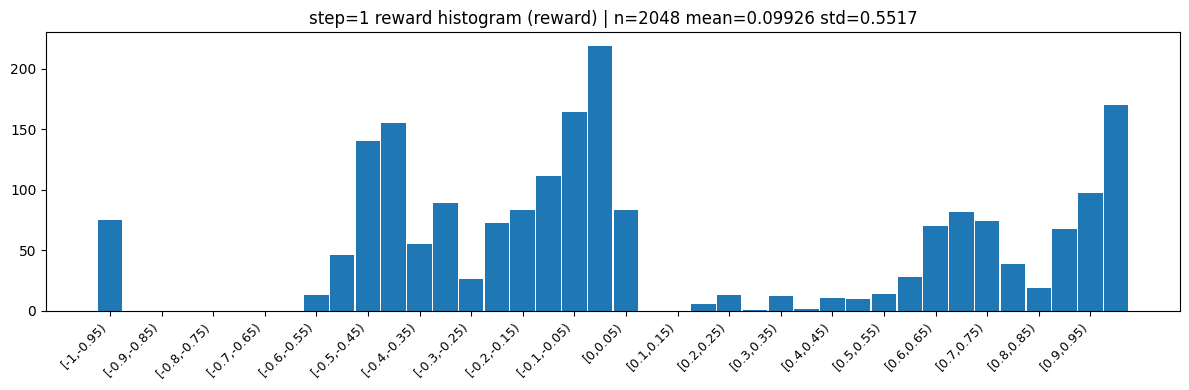

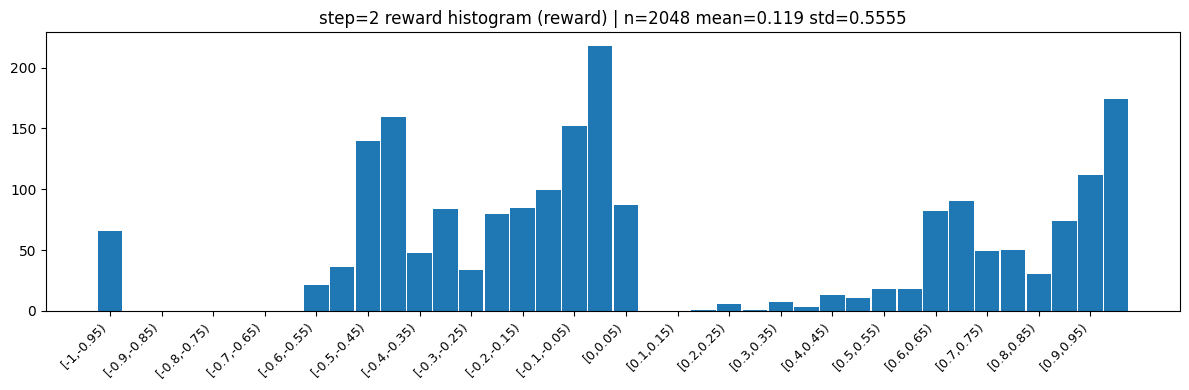

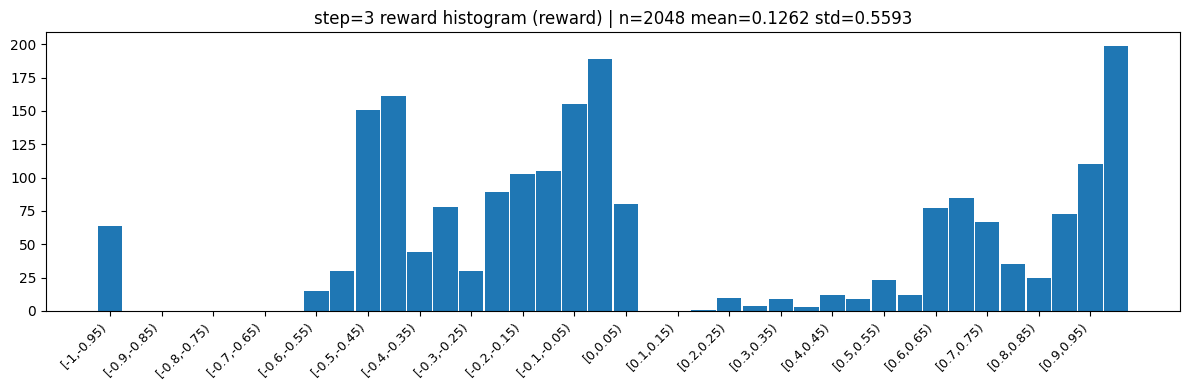

saved dir: /root/autodl-tmp/step-proof/results/fdg_builder_grpo/reward_samples/reward_cnt_nb/hist_by_step


In [ ]:
# 输出各个 step 的 reward 直方图（基于上面统计的 hist）
# - 默认保存到 OUT_DIR/hist_by_step/
# - 同时在 notebook 里展示前几个 step 的图

HIST_DIR = OUT_DIR / "hist_by_step"
HIST_DIR.mkdir(parents=True, exist_ok=True)

x = list(range(N_BINS))

def plot_step_hist(step: int, *, save: bool = True, show: bool = True) -> None:
    agg = per_step[step]
    counts = agg.hist

    plt.figure(figsize=(12, 4))
    plt.bar(x, counts, width=0.95)
    plt.xticks(
        ticks=x[:: max(1, N_BINS // 20)],
        labels=[bin_labels[i] for i in x[:: max(1, N_BINS // 20)]],
        rotation=45,
        ha="right",
        fontsize=9,
    )
    plt.title(
        f"step={step} reward histogram ({REWARD_FIELD}) | n={agg.stats.n} mean={agg.stats.mean:.4g} std={agg.stats.std_pop():.4g}"
    )
    plt.tight_layout()

    if save:
        out_png = HIST_DIR / f"step_{step:04d}.png"
        plt.savefig(out_png, dpi=160)

    if show:
        plt.show()
    else:
        plt.close()


# 展示前 3 个 step（避免 notebook 一次性输出太多图）
for step in steps_sorted[:]:
    plot_step_hist(step, save=True, show=True)

print("saved dir:", HIST_DIR)


In [ ]:
# （可选）输出全局 reward 直方图

plt.figure(figsize=(12, 4))
plt.bar(list(range(N_BINS)), global_hist, width=0.95)
plt.xticks(
    ticks=list(range(0, N_BINS, max(1, N_BINS // 20))),
    labels=[bin_labels[i] for i in range(0, N_BINS, max(1, N_BINS // 20))],
    rotation=45,
    ha="right",
    fontsize=9,
)
plt.title(
    f"GLOBAL reward histogram ({REWARD_FIELD}) | n={global_stats.n} mean={global_stats.mean:.4g} std={global_stats.std_pop():.4g}"
)
plt.tight_layout()

out_png = OUT_DIR / "global_reward_hist.png"
plt.savefig(out_png, dpi=160)
plt.show()
print("wrote:", out_png)
